# **Análisis Exploratorio de Datos**

## **Librerías y módulos necesarios**

In [1]:
import re  
import math                 
import nltk
import string             
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import trange 
from nltk import tokenize                     
from bs4 import BeautifulSoup 
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.probability import FreqDist  
from nltk.tokenize import word_tokenize     
from nltk.stem import WordNetLemmatizer  
from sklearn.preprocessing import LabelEncoder   
from sklearn.feature_extraction.text import CountVectorizer 

In [2]:
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')


[nltk_data] Downloading package wordnet to /home/valcd/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/valcd/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
import warnings
warnings.filterwarnings('ignore')
nltk.download('omw-1.4', quiet=True)
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (17,7)
plt.rcParams['font.size'] = 18

## **Base de datos original**

In [4]:
data = pd.read_csv('../data/Resume.csv')
data

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR
...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


### **Diccionario de Variables**

| **Variable**     | **Descripción** |
|------------------|------------------|
| **ID** | Identificador único y nombre del archivo correspondiente al PDF del currículum. |
| **Resume_str** | Texto del currículum en formato de cadena (string). |
| **Resume_html** | Datos del currículum en formato **HTML**, obtenidos durante el proceso de web scraping. |
| **Category** | Categoría del empleo al que corresponde el currículum. Las categorías incluyen: HR, Designer, Information-Technology, Teacher, Advocate, Business-Development, Healthcare, Fitness, Agriculture, BPO, Sales, Consultant, Digital-Media, Automobile, Chef, Finance, Apparel, Engineering, Accountant, Construction, Public-Relations, Banking, Arts, Aviation. |


## **Sobre los datos**

In [5]:
data.shape

(2484, 4)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


El conjunto de datos a utilizar consta de **2484** currículums y **4** variables descriptivas.

Se observa que no se cuenta con datos nulos, sin embargo, al tratarse de datos textuales, vamos a detectar la presencia de cadenas de texto vacías.

In [7]:
# Verificar cadenas de texto vacías en 'Resume_str' y 'Category'
resumevacio = (data['Resume_str'].str.strip() == "")
categoryvacio = (data['Category'].str.strip() == "")

vacio = resumevacio | categoryvacio

ids_vacios = data.loc[vacio, 'ID']

if ids_vacios.empty:
    print("No se encontró ningún ID con cadenas de textos vacías.")
else:
    print(f"Se encontraron {len(ids_vacios)} filas críticas con strings vacíos.")
    print("Estos son sus IDs:", ids_vacios.tolist())

Se encontraron 1 filas críticas con strings vacíos.
Estos son sus IDs: [12632728]


In [8]:
data[data['ID'].isin(ids_vacios)]

,ID,Resume_str,Resume_html,Category
656,12632728,,"<div class=""fontsize fontface vmargins hmargin...",BUSINESS-DEVELOPMENT


La información obtenida indica que la observación correspondiente al currículum con **ID 12632728**	tiene información faltante en **`Resume_str`**, por tanto, intentaremos extraer la información de **`Resume_html`**. 

Esto solo se hace por práctica pues se sabe que la información que se tiene en ambas variables no varía entre ellas.

In [9]:
# Visualizar el contenido HTML de un currículum específico
html_content = data[data["ID"]==12632728]["Resume_html"].values[0]
soup = BeautifulSoup(html_content, 'html.parser')
all_text = soup.get_text(separator='\n')  
all_text

' \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n '

Este resultado confirma que el currículum adjuntado no contiene información para nuestro ejercicio de interés. Debido a esto, procederemos a eliminarla del conjunto de datos.

A su vez, eliminaremos las columnas de **`ID`** y **`Resume_html`**, pues a este punto ya no tienen importancia dentro de nuestra tarea.

In [10]:
data = data[data['ID'] != 12632728].copy()
data.drop(columns=['ID', 'Resume_html'], inplace=True)
data.reset_index(drop=True, inplace=True)
data

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR
...,...,...
2478,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION
2479,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION
2480,GEEK SQUAD AGENT Professional...,AVIATION
2481,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION


En este orden de ideas, la base de datos que utilizaremos de ahora en adelante contiene un total de **2483** observaciones y las dos variables relevantes para la clasificación de los currículums por área o trabajo aplicado.

A continuación, analizaremos cada variable.

### **Category: Variable Objetivo**

In [11]:
num_categorias = data['Category'].nunique()
print(f"En total, estamos trabajando con {num_categorias} categorías diferentes.\n")

print(data['Category'].unique())

En total, estamos trabajando con 24 categorías diferentes.

['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE'
 'BUSINESS-DEVELOPMENT' 'HEALTHCARE' 'FITNESS' 'AGRICULTURE' 'BPO' 'SALES'
 'CONSULTANT' 'DIGITAL-MEDIA' 'AUTOMOBILE' 'CHEF' 'FINANCE' 'APPAREL'
 'ENGINEERING' 'ACCOUNTANT' 'CONSTRUCTION' 'PUBLIC-RELATIONS' 'BANKING'
 'ARTS' 'AVIATION']


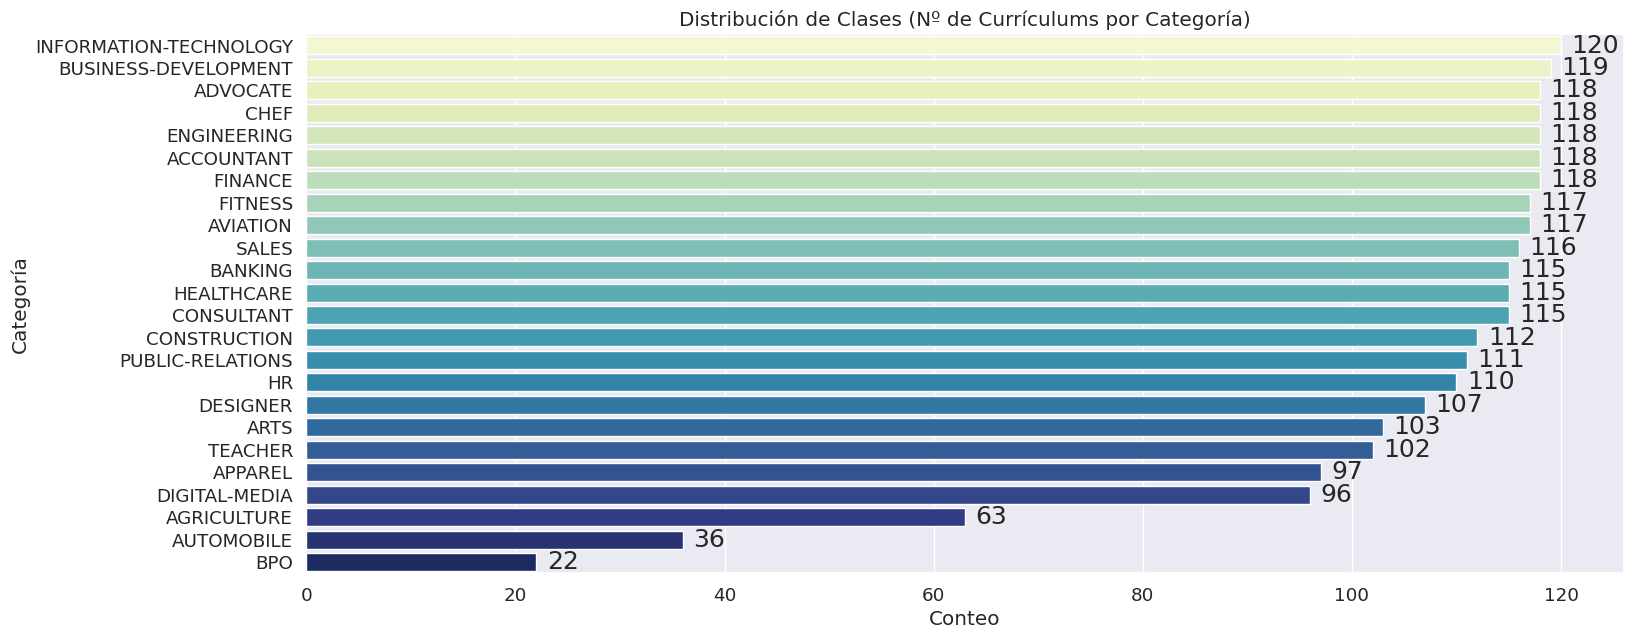

In [12]:
ax = sns.countplot(
    y=data['Category'],
    order=data['Category'].value_counts().index,
    palette='YlGnBu'
)
ax.set_title('Distribución de Clases (Nº de Currículums por Categoría)')
ax.set_xlabel('Conteo')
ax.set_ylabel('Categoría')

for patch in ax.patches:
    count = patch.get_width()
    
    y_pos = patch.get_y() + patch.get_height() / 2
    ax.text(count + 1, y_pos, f'{count:.0f}', ha='left', va='center')

plt.show()

Al analizar la distribución de clases en el gráfico, se observa que el conjunto de datos presenta un desbalanceo moderado.

Se puede ver claramente que las muestras no están repartidas de forma equitativa entre las 24 categorías. Existe una diferencia notable entre la categoría más frecuente (con **120** muestras) y la menos frecuente (con solo **22**). La clase más común es más de 5 veces mayor que la más pequeña.

### **Resume_str: Variable Explicativa**

Para el análisis de esta variable, vamos a considerar dos aspectos fundamentales: la estructura de la información y el contenido de la misma. Esto con el fin de extraer todo el conocimiento posible y relevante.

* #### **Longitud de los textos**

In [13]:
# Cantidad total de caracteres por currículum
data['Character_Count'] = data['Resume_str'].apply(lambda x: len(str(x)))

# Cantidad total de palabras por currículum
data['Word_Count'] = data['Resume_str'].apply(lambda x: len(str(x).split()))

# Promedio de caracteres por palabra por currículum
data['Mean_Character_Per_Word'] = data['Resume_str'].apply(
    lambda x: np.mean([len(word) for word in str(x).split()]) if len(str(x).split()) > 0 else 0
)

# Promedio de palabras por oración por currículum
data['Mean_Words_Per_Sentence'] = data['Resume_str'].apply(
    lambda x: np.mean([len(sent.split()) for sent in tokenize.sent_tokenize(str(x))])
    if len(tokenize.sent_tokenize(str(x))) > 0 else 0
)

In [14]:
data

,Resume_str,Category,Character_Count,Word_Count,Mean_Character_Per_Word,Mean_Words_Per_Sentence
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,5442,674,6.459941,25.923077
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,5572,708,6.307910,26.222222
2,HR DIRECTOR Summary Over 2...,HR,7720,1017,6.218289,26.763158
3,HR SPECIALIST Summary Dedica...,HR,2855,379,5.997361,22.294118
4,HR MANAGER Skill Highlights ...,HR,9172,1206,6.368159,21.927273
...,...,...,...,...,...,...
2478,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION,5533,752,5.655585,30.080000
2479,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION,7108,902,6.505543,19.191489
2480,GEEK SQUAD AGENT Professional...,AVIATION,2020,241,6.431535,16.066667
2481,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION,5074,683,6.008785,22.766667


In [15]:
data.describe()

,Character_Count,Word_Count,Mean_Character_Per_Word,Mean_Words_Per_Sentence
count,2483.000000,2483.000000,2483.000000,2483.000000
mean,6297.835683,811.652437,6.306148,32.660416
std,2766.943443,370.723976,0.370578,43.456547
min,881.000000,113.000000,4.559471,8.516854
25%,5162.500000,651.000000,6.107087,17.336022
50%,5887.000000,757.000000,6.332180,21.542857
75%,7227.500000,933.000000,6.549290,30.106443
max,38842.000000,5190.000000,7.551282,974.000000


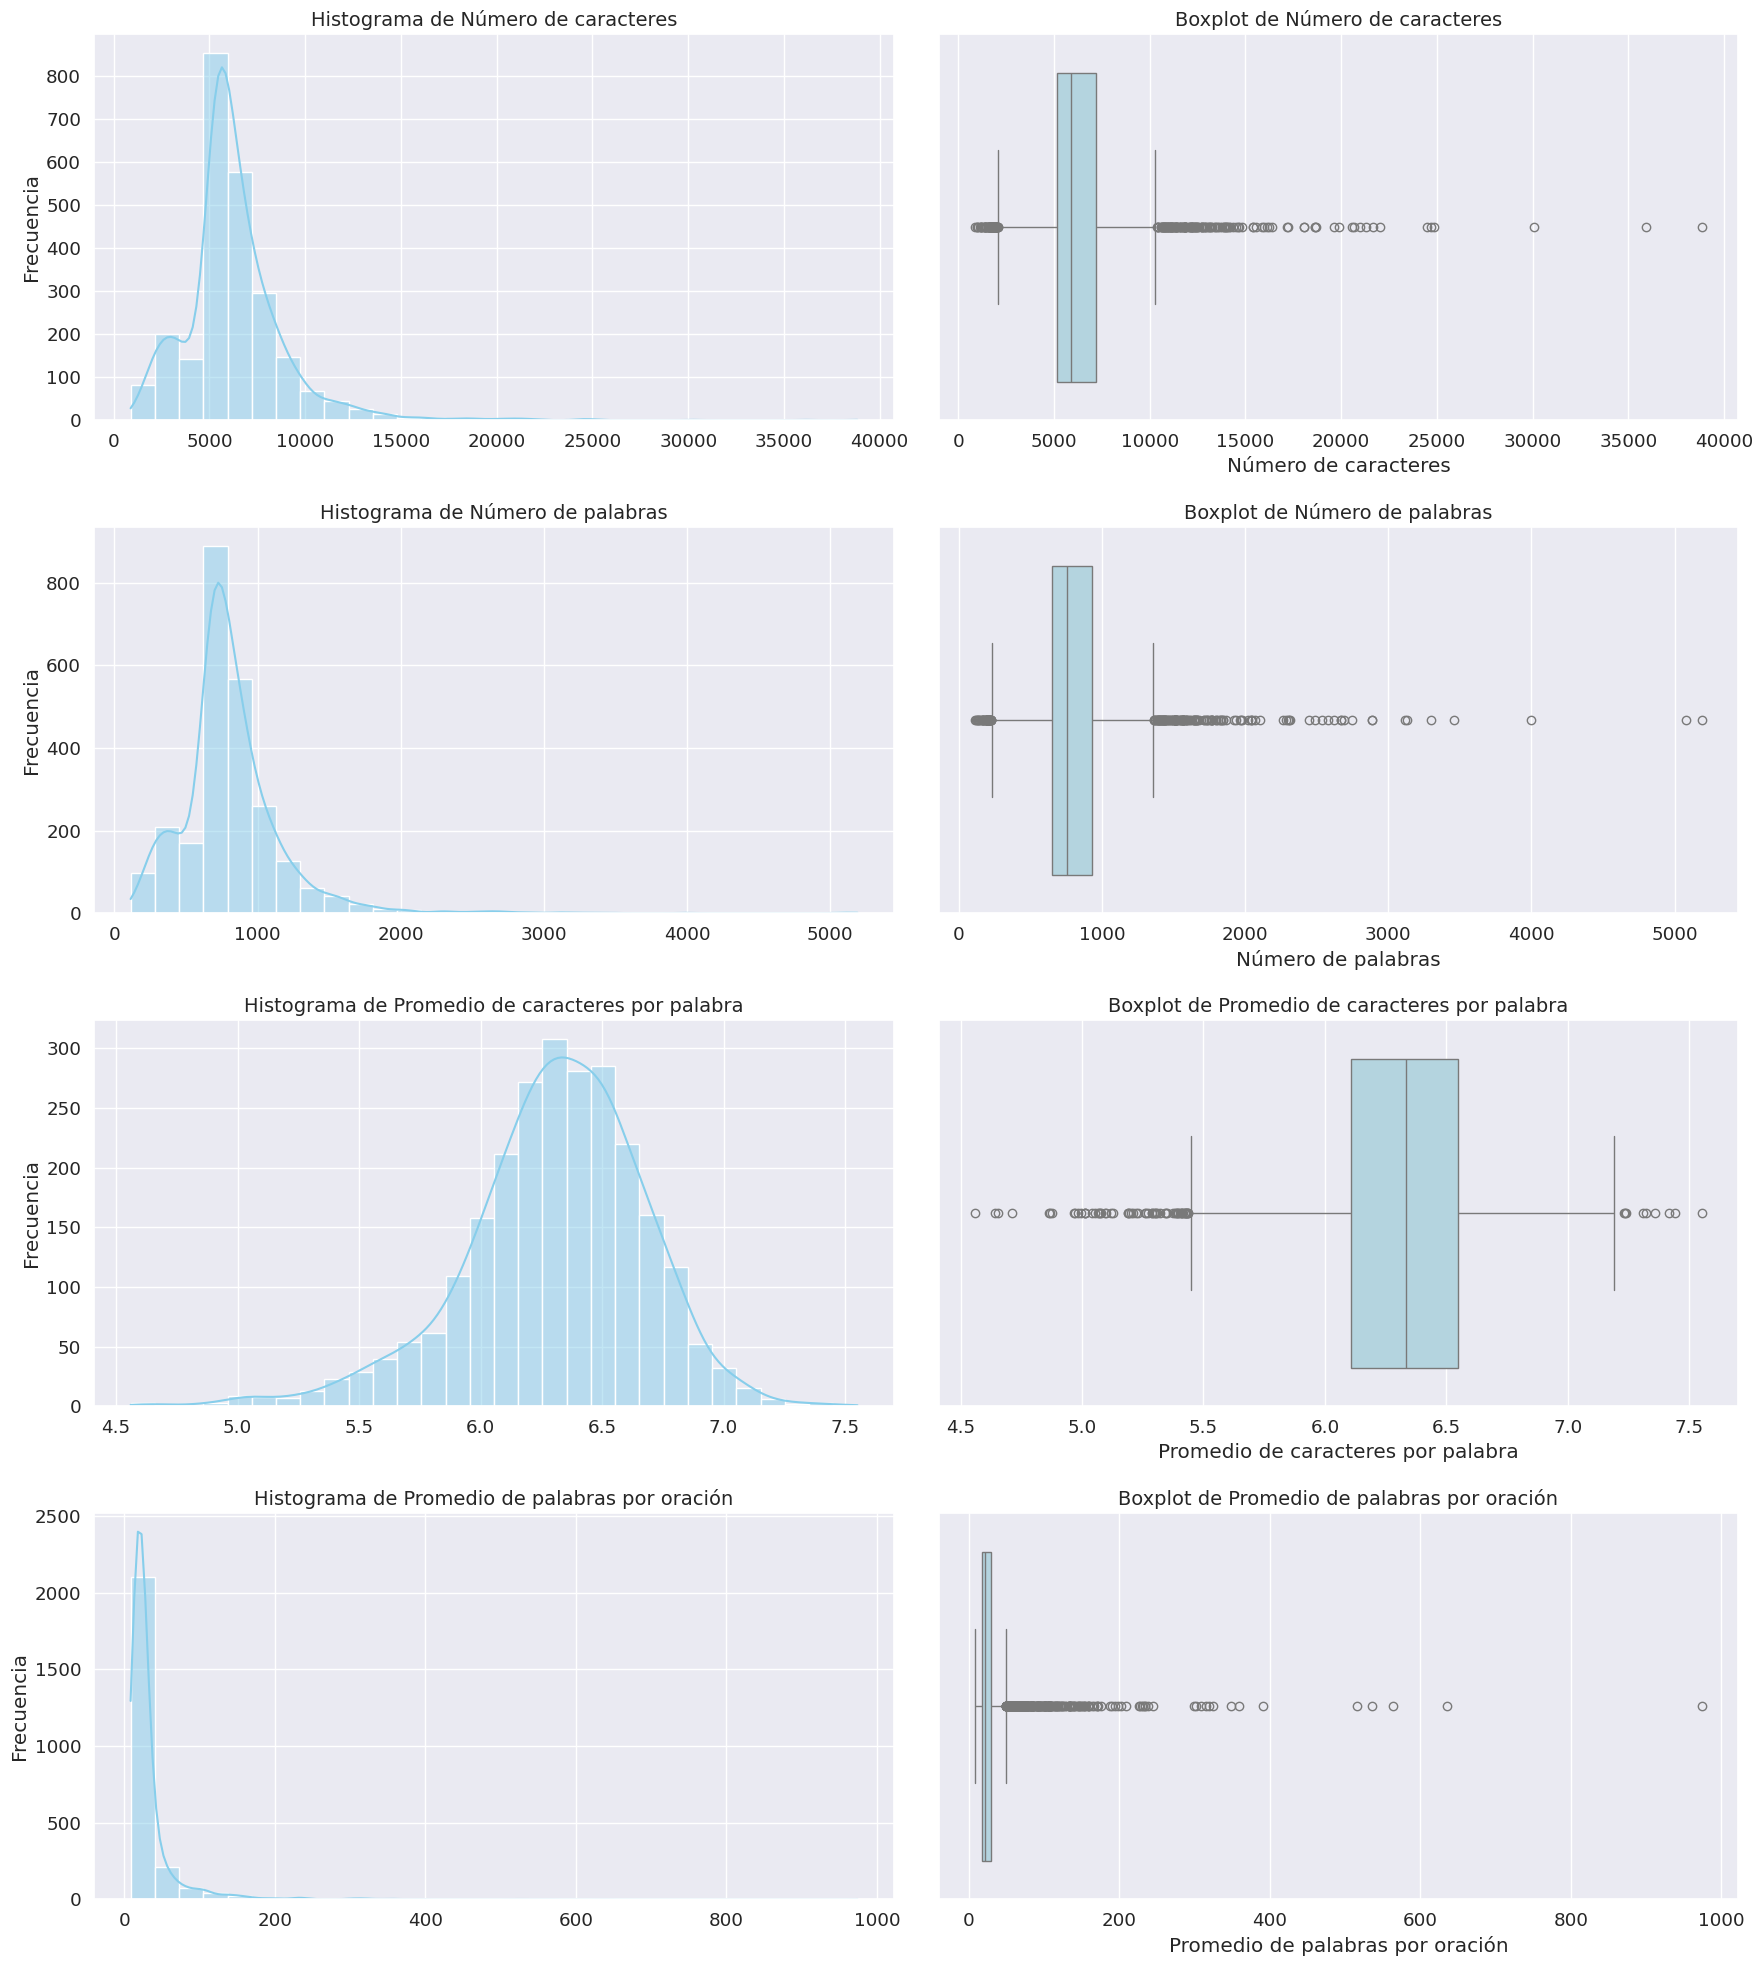

In [16]:
metricas = [
    ('Character_Count', 'Número de caracteres'),
    ('Word_Count', 'Número de palabras'),
    ('Mean_Character_Per_Word', 'Promedio de caracteres por palabra'),
    ('Mean_Words_Per_Sentence', 'Promedio de palabras por oración')
]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 20))

for i, (metric_name, metric_label) in enumerate(metricas):
    
    sns.histplot(data[metric_name], bins=30, kde=True, color='skyblue', ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de {metric_label}', fontsize=14)
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Frecuencia')

    sns.boxplot(x=data[metric_name], color='lightblue', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {metric_label}', fontsize=14)
    axes[i, 1].set_xlabel(metric_label)
    axes[i, 1].set_ylabel('')

plt.tight_layout()
plt.show()

Luego de haber calculado las métricas, los resultados obtenidos respecto al análisis de estas son:

* **Character_Count**: Entre los **2483** currículums, el más corto tiene **881** caracteres, mientras que el más extenso alcanza **38842**. Esta diferencia refleja una alta variabilidad en la longitud de los textos. En promedio, los documentos contienen **6297** caracteres, con una desviación estándar de aproximadamente **2766.94**, lo cual evidencia una dispersión considerable.

    En el histograma, la mayoría de los currículums se agrupan hacia el lado izquierdo, concentrándose principalmente en longitudes menores a **10000** caracteres. Sin embargo, se aprecia una cola larga hacia la derecha, lo que significa que existen algunos currículums excepcionalmente largos que actúan como outliers extremos, alcanzando valores cercanos a los **40000** caracteres.

    En el boxplot, se observa la presencia de valores atípicos en ambos extremos. Los valores inferiores tienden a concentrarse más entre sí, mientras que los superiores muestran una mayor dispersión. Ambos bigotes presentan una longitud similar y no excesiva, lo que sugiere que los datos dentro de los primeros y últimos cuartiles no difieren drásticamente entre sí. El rango intercuartílico (de **5,162.5** a **7,227.5**) es relativamente estrecho, indicando que la mayoría de los currículums presentan longitudes moderadas y consistentes.

* **Word_Count**: En cuanto a la cantidad de palabras, el currículum más corto contiene **113** palabras, mientras que el más extenso alcanza **5190**, lo que evidencia nuevamente una alta variabilidad en la extensión de los textos. El promedio de palabras por currículum es de **811.65**, con una desviación estándar de **370.72**, lo que indica una dispersión considerable alrededor de la media.

    El histograma muestra que la mayoría de los currículums se concentran por debajo de las **1000** palabras, mientras que una pequeña proporción presenta longitudes muy superiores, lo que genera una cola larga hacia la derecha. Esto confirma lo observado en las estadísticas descriptivas donde la mediana es mucho menor que los pocos casos extremos que sobrepasan las **5000** palabras.

    El diagrama de caja y bigotes refleja este mismo comportamiento. Se observan valores atípicos en ambos extremos, con los inferiores más agrupados entre sí y los superiores más dispersos. Los bigotes presentan una longitud similar y moderada, lo que sugiere que los valores dentro de los primeros y últimos cuartiles no presentan diferencias muy marcadas. En general, el rango intercuartílico es relativamente estrecho, lo que indica cierta consistencia entre la mayoría de los currículums.
    
    Además, tal como se observa en la tabla de medidas, el **75%** de los currículums contiene menos de **1000** palabras, confirmando que los casos extremadamente largos son atípicos.


* **Mean_Character_Per_Word**: Los resultados varían entre **4.55** y **7.55** caracteres, un rango bastante estrecho que muestra poca variabilidad en la longitud de las palabras usadas. El promedio global es de **6.3** caracteres, con una desviación estándar de **0.37**, lo que significa que la mayoría de los currículums utilizan palabras de una longitud muy similar. Además, la media (**6.3**) y la mediana (**6.33**) son casi iguales, lo que confirma que los datos están bien equilibrados y simétricos.

    El histograma muestra una distribución casi normal, con una forma de campana centrada alrededor de **6.3** caracteres aproximadamente. Esto indica que, sin importar la extensión del currículum o la categoría correspondiente, las personas tienden a usar palabras de longitud media de manera bastante constante. En otras palabras, hay una consistencia en el estilo de escritura entre todos los currículums de la base de datos.

    Por su parte, el boxplot confirma lo anterior pues aunque se observan algunos valores atípicos tanto por debajo como por encima del promedio, estos no afectan significativamente la tendencia general. Los bigotes son de longitud similar y la caja es casi simétrica, lo que refuerza la idea de que los datos están bien distribuidos. Entre el primer cuartil (**6.1**) y el tercer cuartil (**6.54**) se concentra el **50%** central de los currículums, lo que demuestra que la longitud promedio de las palabras es muy parecida en la mayoría de los casos.

* **Mean_Words_Per_Sentence**: El promedio de palabras por oración muestra bastante variación entre los currículums. En promedio, cada oración tiene unas **32** palabras, pero la desviación estándar es alta (**43.45**), lo que indica que no todos siguen el mismo patrón: algunos textos usan oraciones cortas y directas, mientras que otros se extienden mucho más.

    En el histograma se nota claramente una distribución sesgada hacia la derecha, es decir, la mayoría de los currículums tienden a tener oraciones cortas, pero hay algunos casos donde las oraciones son muy largas, incluso llegando a más de **900** palabras por oración, lo cual es bastante inusual.

    El boxplot refuerza esta idea: la mayoría de los valores están concentrados al inicio del eje, mientras que los outliers superiores muestran esos pocos currículums con oraciones excesivamente largas. En general, esto sugiere que la forma de redactar varía bastante entre personas; sin embargo, la tendencia general apunta a un estilo más conciso, con frases relativamente cortas y directas.

    Es importante mencionar que algunos de estos valores tan altos podrían deberse a errores en la segmentación de oraciones (por ejemplo, por ausencia de signos de puntuación o fallos en la función `sent_tokenize`). Por esta razón, se considera que esta variable puede no ser completamente fiable y, por lo tanto, se decide descartarla del análisis.

In [17]:
data.drop(columns=['Mean_Words_Per_Sentence'], inplace=True)    

* #### **Palabras más frecuentes y N-gramas relevantes**

Para encontrar esta información, primero se hará una limpieza de los datos. 

In [18]:
df = data[['Resume_str', 'Category']].copy()

# Preprocesamiento general de texto -- Válido para los 5 modelos

stop_words = set(stopwords.words('english'))

def limpiezatexto(texto):
    
    if not isinstance(texto, str):
        return ""
    
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto) # elimina URLs
    texto = re.sub(r'\S+@\S+', '', texto) # elimina correos electrónicos
    texto = re.sub(r'\d+', '', texto)  # elimina números
    texto = re.sub(r'[^\w\s]', ' ', texto)  # elimina puntuación
    tokens = texto.split() # separa en tokens
    tokens = [w for w in tokens if w not in stop_words] # elimina stopwords
    return " ".join(tokens)

df['Resume_str_clean'] = df['Resume_str'].apply(limpiezatexto)
df

,Resume_str,Category,Resume_str_clean
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,HR,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...
...,...,...,...
2478,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION,rank sgt e non commissioned officer charge bri...
2479,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION,government relations communications organizati...
2480,GEEK SQUAD AGENT Professional...,AVIATION,geek squad agent professional profile support ...
2481,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION,program director office manager summary highly...


##### **Palabras más frecuentes**

100%|██████████| 2483/2483 [00:00<00:00, 73914.87it/s]


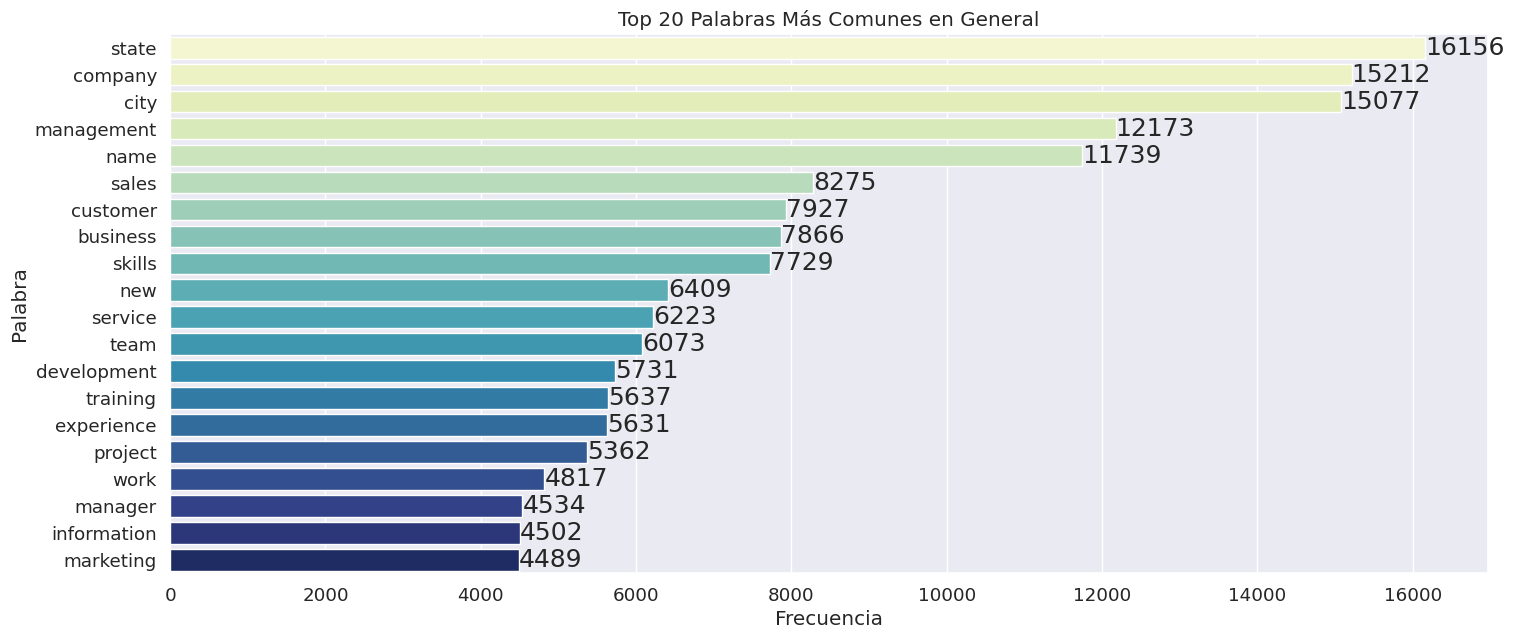

In [19]:
# Conversión a listas de palabras
df['Resume_lists'] = df['Resume_str_clean'].str.split()

# Agrupar listas de palabras en un solo corpus
corpus = []
for i in trange(df.shape[0]):
    corpus += df['Resume_lists'][i]

# Contar la frecuencia de cada palabra
freqpalabras = FreqDist(corpus)

# Top 20 Palabras Más Comunes
topcomunes = freqpalabras.most_common(20)
dftop = pd.DataFrame(topcomunes, columns=['Palabra', 'Frecuencia'])

ax = sns.barplot(
    x='Frecuencia', 
    y='Palabra', 
    data=dftop, 
    palette='YlGnBu'
)

plt.title('Top 20 Palabras Más Comunes en General')
plt.xlabel('Frecuencia')
plt.ylabel('Palabra')

for patch in ax.patches:
    count = patch.get_width()
    
    y_pos = patch.get_y() + patch.get_height() / 2
    ax.text(count + 1, y_pos, f'{count:.0f}', ha='left', va='center')

plt.show()

A partir del diagrama de barras, podemos ver que la palabra más frecuente considerando todos los currículums es **`state`** (**16156**), lo cual tiene bastante sentido, ya que en este tipo de documentos es común hacer referencia a lugares relacionados con el nacimiento, la educación o el trabajo. De hecho, muchas personas mencionan instituciones o experiencias que incluyen nombres de estados o ciudades, lo que explica también la alta frecuencia de palabras como **`company`** (**15212**) y **`city`** (**15077**), que suelen aparecer al describir ubicaciones laborales o académicas.

Por otro lado, destacan términos más vinculados con el contenido profesional de los currículums, como **`management`** (**12173**), **`customer`** (**7927**), **`business`** (**7866**), **`development`** (**5731**) y **`project`** (**5362**). Estas palabras reflejan habilidades de liderazgo, buen trabajo con clientes y desarrollo de proyectos, lo que sugiere que muchos candidatos buscan resaltar sus capacidades en de gestión, creación y/o coordinación dentro de un entorno laboral.

También aparecen con frecuencia palabras como **`skills`** (**7729**), **`team`** (**6073**) y **`experience`** (**5631**), lo cual muestra que buena parte de los currículums hacen énfasis en competencias interpersonales y trabajo en equipo, algo muy valorado en la mayoría de las profesiones y compañías.

##### **Bigramas**

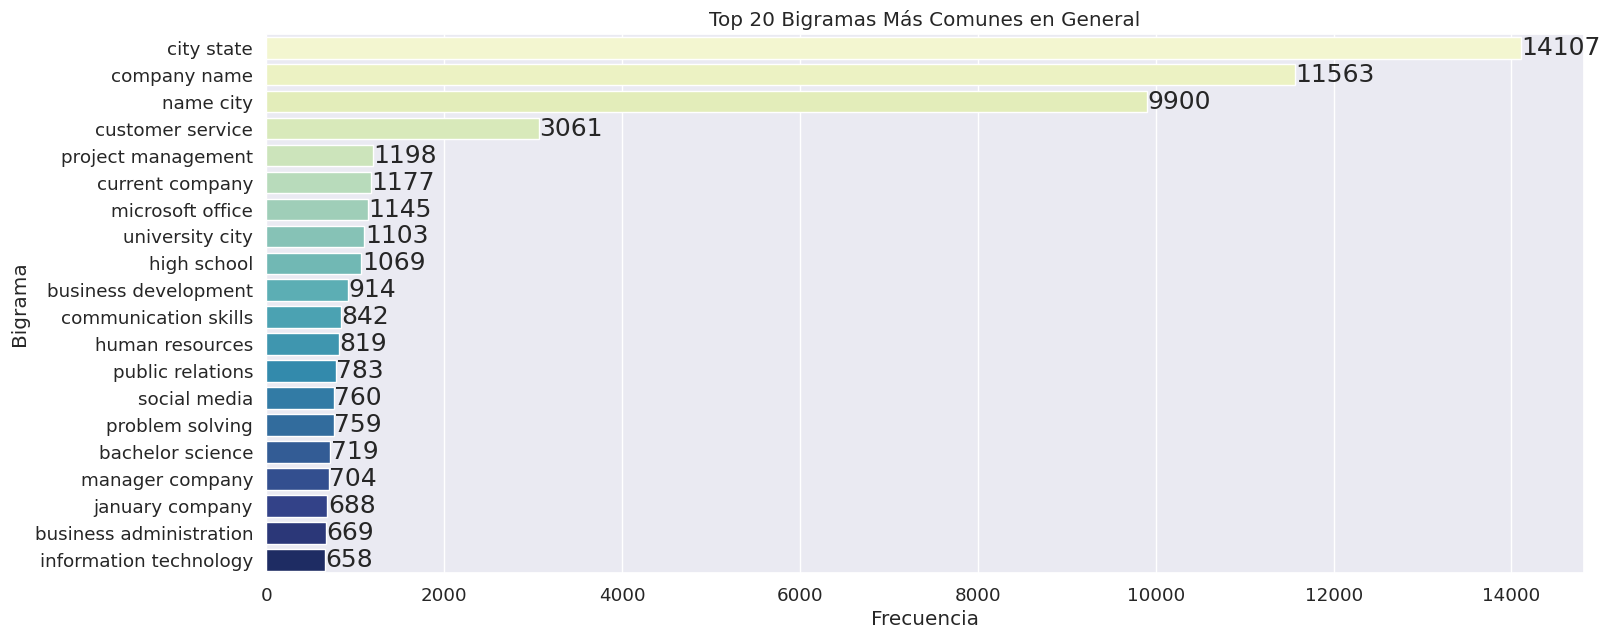

In [20]:
# Inicializar el CountVectorizer 
cv = CountVectorizer(ngram_range=(2,2))

bigrama = cv.fit_transform(df['Resume_str_clean'])
sum_bigramas = bigrama.sum(axis=0) 
contador = np.asarray(sum_bigramas).ravel()

# DataFrame de frecuencias
ngram_freq = pd.DataFrame(sorted([(contador[i], k) for k, i in cv.vocabulary_.items()], reverse = True))
ngram_freq.columns = ["frequency", "ngram"]

ax = sns.barplot(x=ngram_freq['frequency'][:20], y=ngram_freq['ngram'][:20], palette='YlGnBu')

ax.set_title('Top 20 Bigramas Más Comunes en General')
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Bigrama')

for patch in ax.patches:
    
    count = patch.get_width()
    y_pos = patch.get_y() + patch.get_height() / 2
    ax.text(count + 5, y_pos, f'{count:.0f}', ha='left', va='center')

plt.show()

En el gráfico de bigramas más frecuentes se observa que las combinaciones **`city state`** (**14107**), **`company name`** (**11563**) y **`name city`** (**9900**) son las más comunes. Esto tiene sentido, ya que en la mayoría de los currículums se incluyen datos personales, direcciones o nombres de empresas, por lo que es normal que aparezcan juntas palabras relacionadas con lugares y compañías.

Después de estas, encontramos bigramas como **`customer service`** (**3061**), **`project management`** (**1198**), **`business development`** (**914**) o **`human resource`** (**819**),, que reflejan áreas laborales y habilidades clave que los candidatos suelen destacar. Estos términos indican que una buena parte de los currículums proviene de personas con experiencia en gestión, atención al cliente y desarrollo organizacional.

También aparecen combinaciones como **`microsoft office`** (**1147**), **`communication skills`** (**842**) o **`public relations`** (**783**), que refuerzan la tendencia a mencionar competencias técnicas e interpersonales.

Además, expresiones como **`high school`** (**1080**) o **`bachelor science`** (**769**) muestran la presencia de información educativa, algo básico en este tipo de documentos.

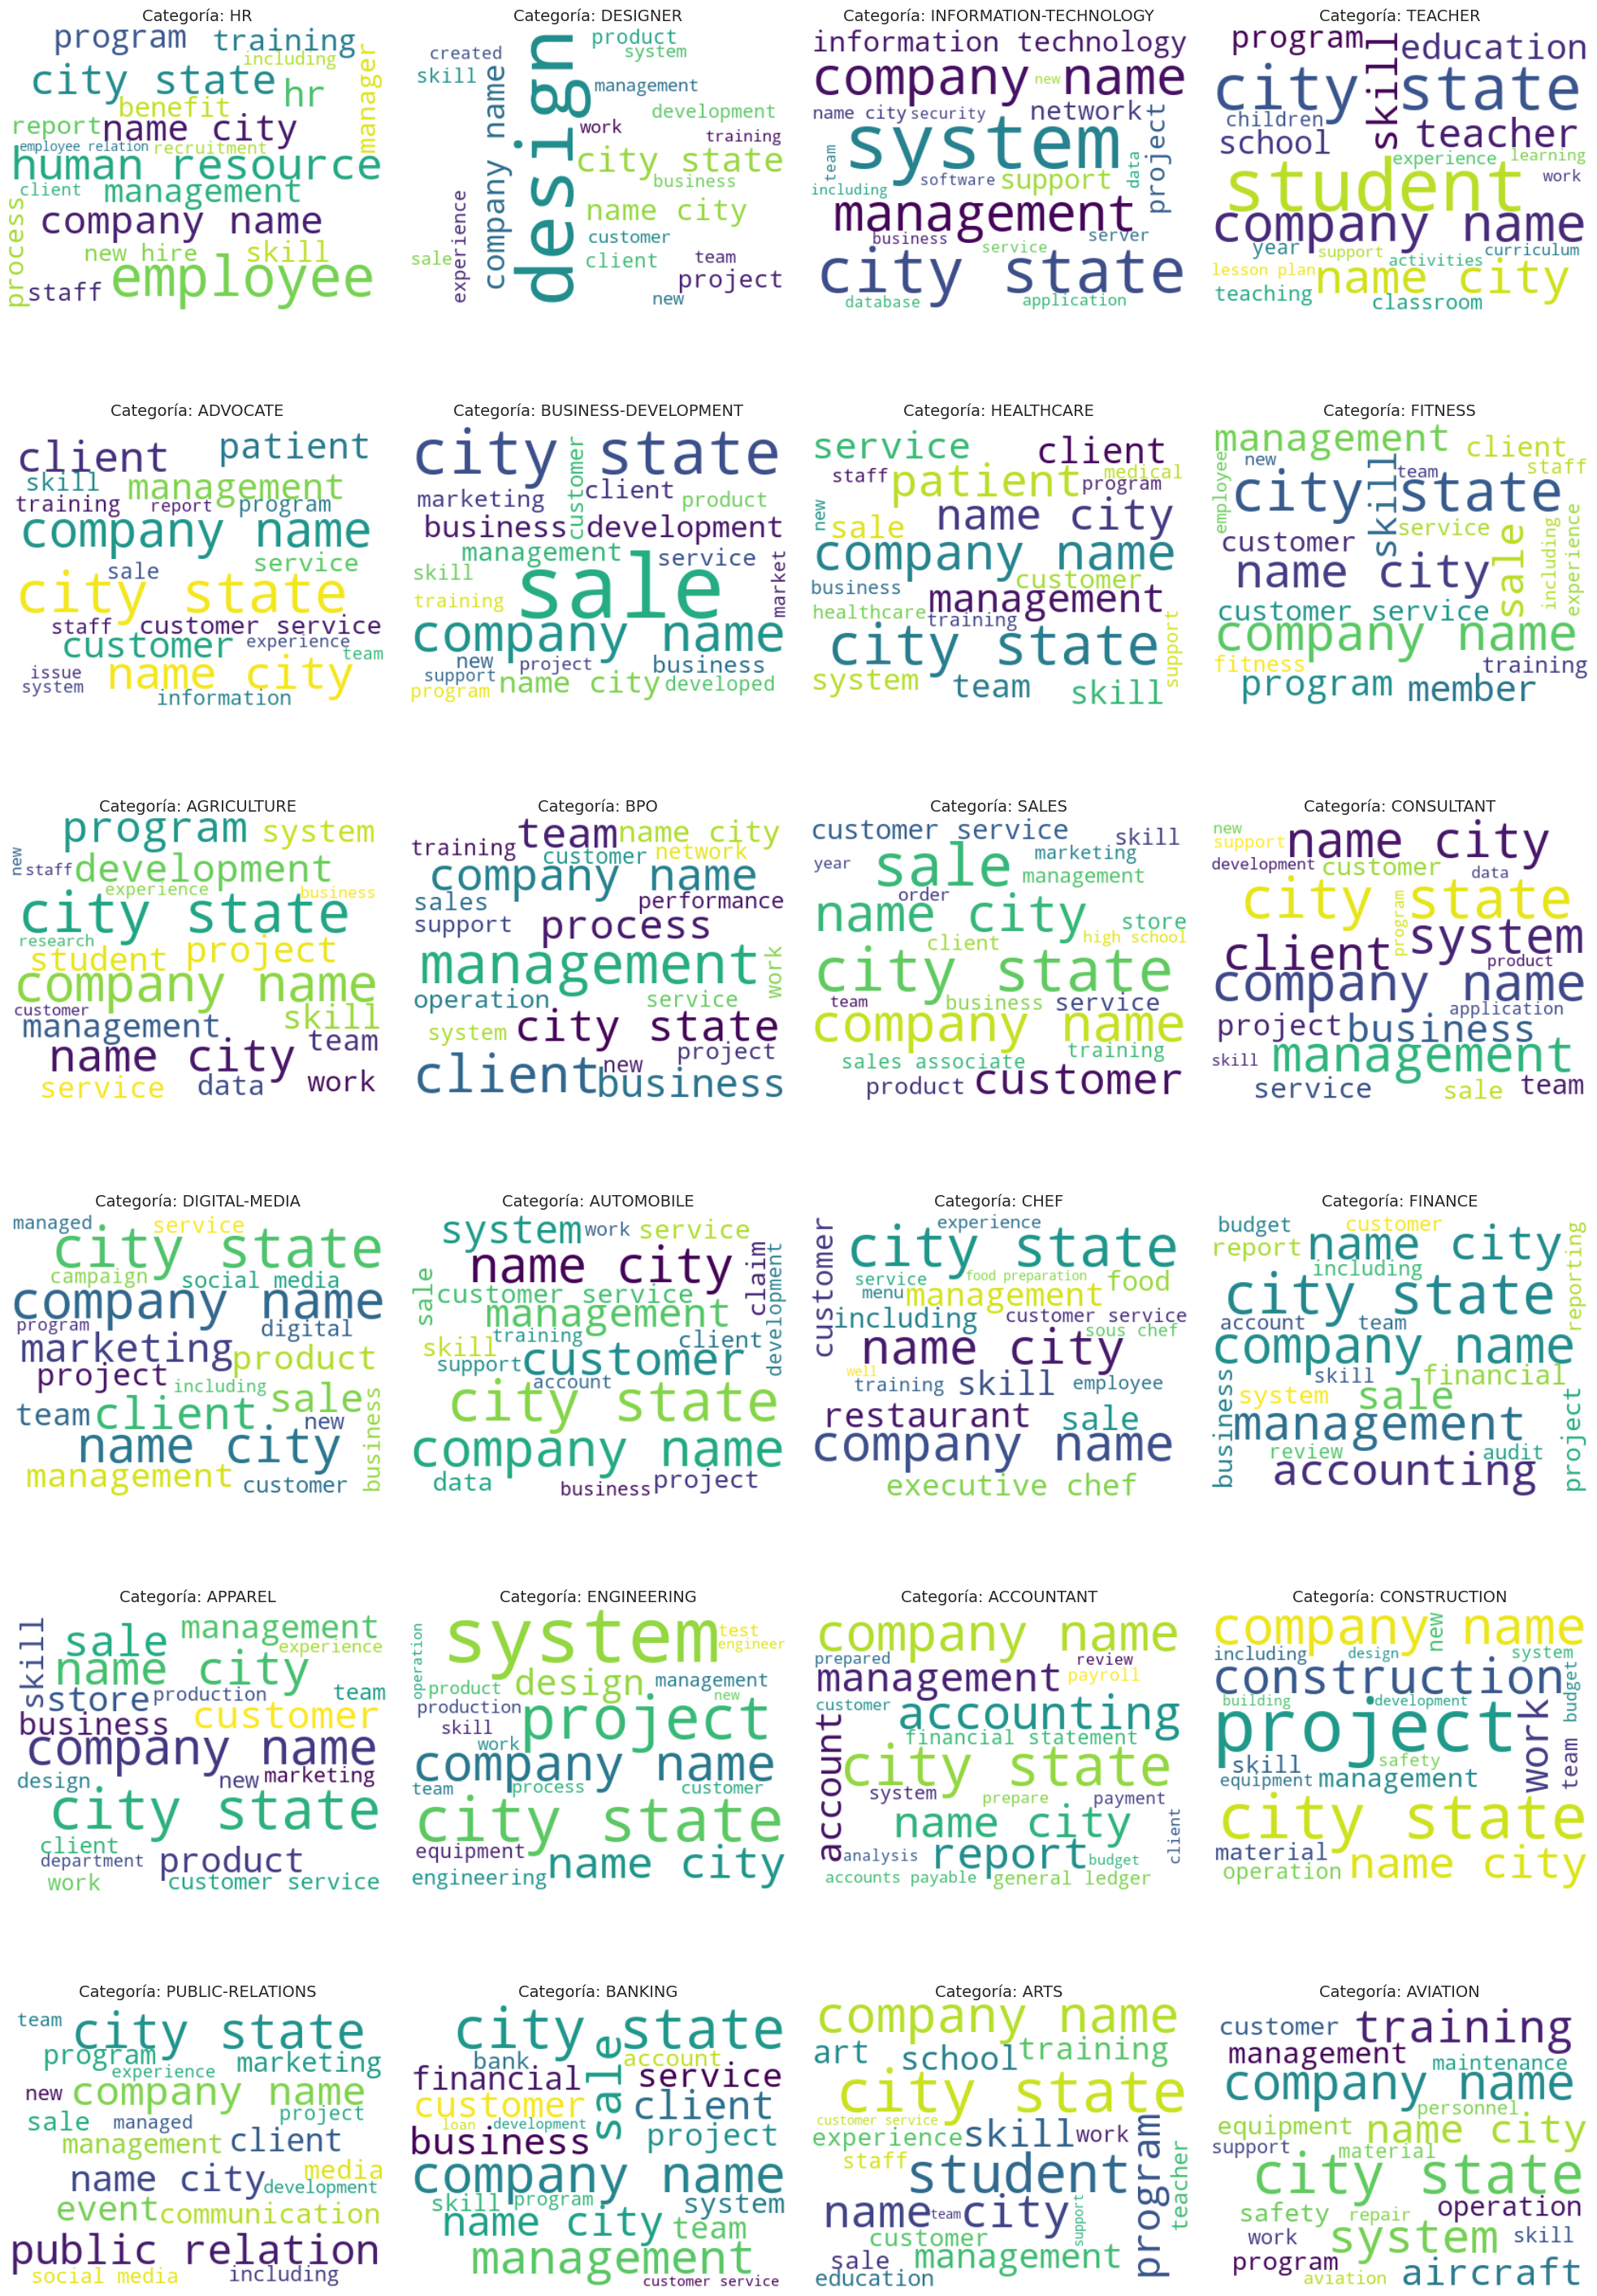

In [21]:
categorias = df['Category'].unique()

n_cols = 4
n_rows = math.ceil(num_categorias / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 30))
axes = axes.flatten()

for i, categoria in enumerate(categorias):
    
    ax = axes[i]
    texto_categoria = " ".join(df[df['Category'] == categoria]['Resume_str_clean'])
    if not texto_categoria:
        ax.set_title(f"Categoría: {categoria} (Sin texto)")
        ax.axis('off')
        continue
    
    wordcloud_cat = WordCloud(
        width=400,
        height=300,
        background_color='white',
        max_words=20,
        colormap='viridis'
    ).generate(texto_categoria)

    ax.imshow(wordcloud_cat, interpolation='bilinear')
    ax.set_title(f"Categoría: {categoria}", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

Finalmente, luego de haber analizado el contenido de los currículums de manera general, estas nubes de palabras nos permiten identificar las palabras y bigramas más frecuentes en cada categoría. A partir de ellas, se observa que cada área tiene términos característicos que reflejan sus propias dinámicas y enfoques.

## **Base de datos final**

Como paso final de este Análisis Exploratorio de Datos, se hará el preprocesamiento faltante correspondiente al dataset con el fin de tener información de utilidad para la implementación posterior de los modelos.

Cabe mencionar que ya se hizo la limpieza de los datos; de ahí obtuvimos el conjunto `df`. Ahora, realizaremos la codificación de la variable **`Category`** para que los modelos puedan identificar y clasificar correctamente.

In [22]:
encoder = LabelEncoder()
df['Category_code'] = encoder.fit_transform(df['Category'])
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
df.drop(columns=['Resume_lists'], inplace=True)
df.to_csv('dataprocesada.csv', index=False)
df

,Resume_str,Category,Resume_str_clean,Category_code
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administrator marketing associate hr admini...,19
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...,19
2,HR DIRECTOR Summary Over 2...,HR,hr director summary years experience recruitin...,19
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...,19
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...,19
...,...,...,...,...
2478,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION,rank sgt e non commissioned officer charge bri...,6
2479,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION,government relations communications organizati...,6
2480,GEEK SQUAD AGENT Professional...,AVIATION,geek squad agent professional profile support ...,6
2481,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION,program director office manager summary highly...,6
